# Window Shopping — a quantitative teardown \U0001F52C
### Three parameters · six windows · out-of-sample scoring · paired Diebold-Mariano · Blume shrinkage

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Usefulness: Fragile](https://img.shields.io/badge/Usefulness-Fragile-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The
organising idea is bias-variance: a window is a bet that the recent past resembles the near
future more than the distant past does, and how good that bet is depends entirely on how
precisely the parameter can be estimated in the first place.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance, pinned as-of the date
> in [`docs/results.md`](../docs/results.md); literature map in
> [`docs/references.md`](../docs/references.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from window_choice import data, strategy as st

px = data.load_prices()
rets = st.to_returns(px)
sectors = tuple(s for s in data.SECTORS if rets[s].notna().sum() > 500)
print(f"as-of {data.AS_OF} | {len(sectors)} sectors | "
      f"{px.index[0].date()} -> {px.index[-1].date()}")
print("inceptions:", ", ".join(f"{s}:{px[s].dropna().index[0].year}" for s in data.SECTORS))

as-of 2026-06-30 | 11 sectors | 1993-01-29 -> 2026-06-30
inceptions: XLB:1998, XLC:2018, XLE:1998, XLF:1998, XLI:1998, XLK:2000, XLP:1998, XLRE:2015, XLU:1998, XLV:2000, XLY:1998


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Real | Yes, and by more than habit would suggest. Across estimation windows the MSE spread is **72%** for beta, **92%** for the mean return and **3%** for the volatility of the minimum-variance portfolio; the strongest pairwise Diebold-Mariano across the three experiments is **+3.45**. The three quantities do not agree with each other: beta wants **2**, the mean wants **10**, the covariance matrix wants **3**. |
| **Usefulness** | Fragile | There is no single default. The mean is the extreme case: even the *best* window of a sector's own history is beaten by the **grand mean across all sectors** (MSE ratio 1.54), which is the empirical way of saying individual expected returns are not estimable from price history at all. Beta is estimable and mildly non-stationary — Blume shrinkage cuts its MSE by a further **-10%**. The covariance matrix is the one place where a short window is actively dangerous: at 11 assets, a one-year window has about 42.0 observations per estimated parameter. |

> \U0001F4A1 **In plain words.** "How much history?" is really "how precisely can this thing be
> estimated, and how fast does it move?" — and those two answers are different for a mean, a
> beta and a covariance matrix.

## 1 · The claim, steelmanned

- **H₁.** Out-of-sample MSE is a U-shaped function of window length for a parameter that drifts
  (beta) and monotonically decreasing for one that does not (the mean).
- **H₂.** For the covariance matrix the binding constraint is **rows per parameter**, so the
  realised volatility of a minimum-variance portfolio falls with window length far past the
  point where a beta would want to stop.
- **H₃.** Shrinkage dominates window selection: Blume for beta, the grand mean for expected
  returns.

## 2 · So what? — the quantitative stakes

A minimum-variance portfolio built on a one-year window and one built on ten years are
*different portfolios* — different concentration, different turnover, different realised risk.
None of that difference is a view about markets; all of it is a consequence of an unexamined
default.

## 3 · How we'd know — the protocol

1. Decision dates are **year-ends**; the evaluation period is the following calendar year.
2. `train_slice` cuts strictly at the decision date;
   `test_beta_experiment_is_out_of_sample` mangles the future and checks nothing earlier moves.
3. Covariance is scored on the **realised volatility of the portfolio it produced**, not on a
   matrix distance — the loss function a user actually has.
4. Comparisons use **paired** squared errors (same sector, same year) and a HAC
   Diebold-Mariano, because two windows share most of their data.

## 4 · The teardown

### 4.1 Beta: the U-shape, and what shrinkage does to it

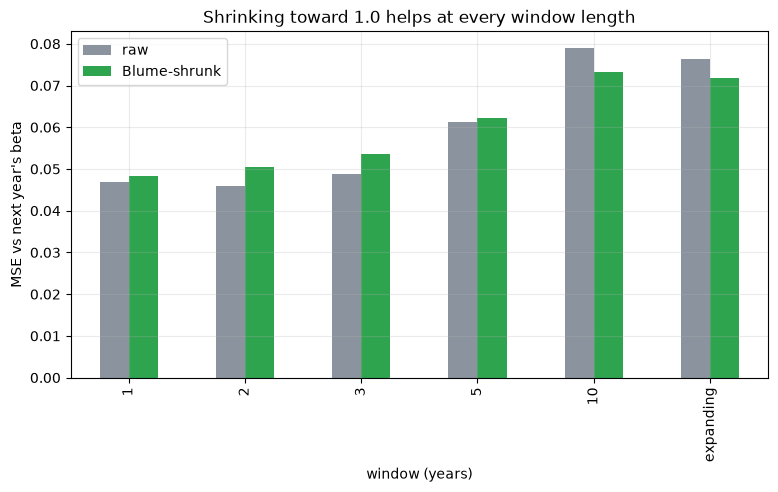

             raw  Blume-shrunk
window                        
1         0.0470        0.0483
2         0.0460        0.0504
3         0.0488        0.0535
5         0.0612        0.0622
10        0.0791        0.0733
expanding 0.0765        0.0718

DM(1 vs expanding) = -3.45  p=0.001  n=256
DM(2 vs expanding) = -3.55  p=0.000  n=256
DM(3 vs expanding) = -3.55  p=0.000  n=256
DM(5 vs expanding) = -2.55  p=0.011  n=256


DM(10 vs expanding) = +1.17  p=0.244  n=256


In [3]:
bexp = st.beta_experiment(rets, sectors, data.MARKET)
bsc = st.score(bexp)
bexp["shrunk_error"] = bexp["estimate"].map(st.blume_shrunk) - bexp["realised"]
shr = bexp.groupby("window")["shrunk_error"].apply(lambda s: float((s ** 2).mean()))
comp = pd.DataFrame({"raw": bsc["mse"], "Blume-shrunk": shr}).loc[bsc.index]
fig, ax = plt.subplots(figsize=(9, 4.5))
comp.plot.bar(ax=ax, color=["#8b949e", "#2ea44f"])
ax.set_ylabel("MSE vs next year's beta"); ax.set_xlabel("window (years)")
ax.set_title("Shrinking toward 1.0 helps at every window length")
ax.legend(title="")
plt.show()
print(comp.round(5).to_string())
print()
for w in bsc.index:
    if w != st.EXPANDING:
        d = st.pairwise_dm(bexp, w, st.EXPANDING)
        print(f"DM({w} vs expanding) = {d['dm']:+.2f}  p={d['p_value']:.3f}  n={d['n']}")

### 4.2 The dispersion of realised betas — is there anything to track?

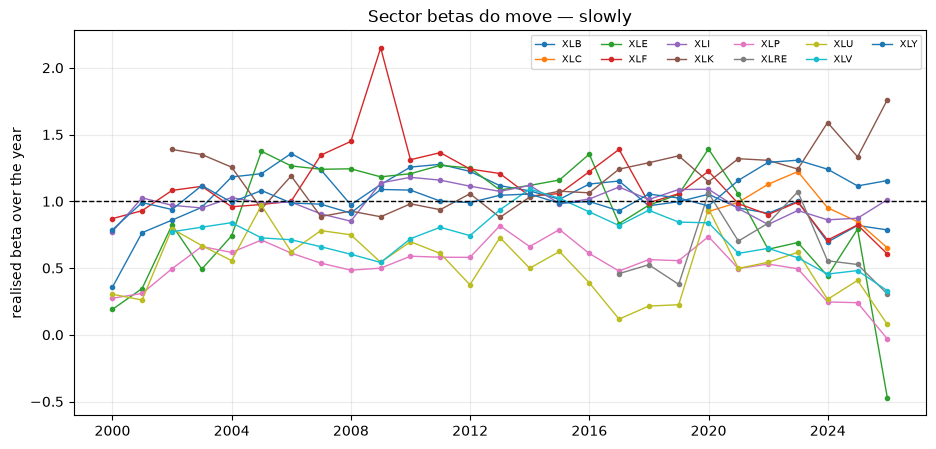

sector,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
sd of realised beta across years,0.2150,0.1860,0.4340,0.2930,0.1070,0.2270,0.1850,0.2690,0.2390,0.1820,0.1160


In [4]:
piv = bexp[bexp["window"] == 5].pivot_table(index="date", columns="sector",
                                             values="realised")
fig, ax = plt.subplots(figsize=(11, 5))
for c in piv.columns:
    ax.plot(piv.index, piv[c], marker="o", ms=3, lw=1, label=c)
ax.axhline(1.0, color="k", lw=1, ls="--")
ax.set_ylabel("realised beta over the year"); ax.set_title("Sector betas do move — slowly")
ax.legend(ncol=6, fontsize=7)
plt.show()
piv.std().round(3).to_frame("sd of realised beta across years").T

> \U0001F4A1 **In plain words.** If betas never moved, the expanding window would win outright.
> They move enough to punish a ten-year memory and not enough to reward a one-year one.

### 4.3 Means: the estimator that ignores your data wins

              mse    bias    mae    n  annualised_bias
window                                                
1          0.0000 -0.0000 0.0008  256          -0.0042
2          0.0000 -0.0000 0.0008  256          -0.0063
3          0.0000 -0.0000 0.0007  256          -0.0088
5          0.0000 -0.0000 0.0007  256          -0.0115
10         0.0000 -0.0001 0.0006  256          -0.0208
expanding  0.0000 -0.0001 0.0006  256          -0.0350
grand mean 0.0000 -0.0000 0.0007  270          -0.0029

DM(grand mean vs best own-history window '10') = -1.39 (p=0.166); negative means the grand mean is better


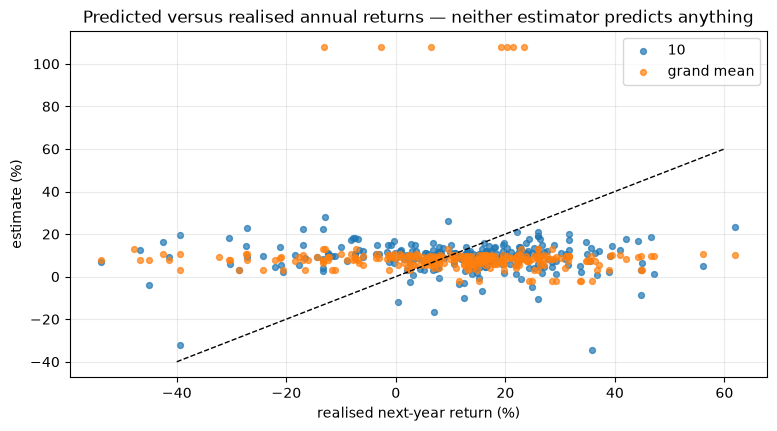

In [5]:
mexp = st.mean_experiment(rets, sectors)
gm = st.grand_mean_benchmark(rets, sectors)
both = pd.concat([mexp, gm], ignore_index=True)
msc = st.score(both)
best_own = msc.drop(index=["grand mean"])["mse"].idxmin()
d = st.pairwise_dm(both, "grand mean", best_own)
print(msc.assign(annualised_bias=lambda x: x["bias"] * 252).round(8).to_string())
print(f"\nDM(grand mean vs best own-history window '{best_own}') = {d['dm']:+.2f} "
      f"(p={d['p_value']:.3f}); negative means the grand mean is better")
fig, ax = plt.subplots(figsize=(9, 4.5))
sub = both[both["window"].isin([best_own, "grand mean"])]
for name, g in sub.groupby("window"):
    ax.scatter(g["realised"] * 252 * 100, g["estimate"] * 252 * 100, s=18, alpha=0.7,
               label=str(name))
lim = [-40, 60]
ax.plot(lim, lim, color="k", lw=1, ls="--")
ax.set_xlabel("realised next-year return (%)"); ax.set_ylabel("estimate (%)")
ax.set_title("Predicted versus realised annual returns — neither estimator predicts anything")
ax.legend()
plt.show()

### 4.4 Covariance: optimism versus rows per parameter

           realised  predicted  shorts  turnover  n_assets  optimism  rows_per_param
window                                                                              
1            0.1349     0.1169  0.4191    1.4820    9.4815   -0.1336          3.8182
2            0.1345     0.1226  0.4118    0.9684    9.4815   -0.0889          7.6364
3            0.1344     0.1272  0.3967    0.7855    9.4815   -0.0536         11.4545
5            0.1371     0.1339  0.3917    0.6490    9.4815   -0.0237         19.0909
10           0.1388     0.1388  0.3285    0.4751    9.4815   -0.0001         38.1818
expanding    0.1384     0.1415  0.3133    0.4345    9.4815    0.0221             NaN


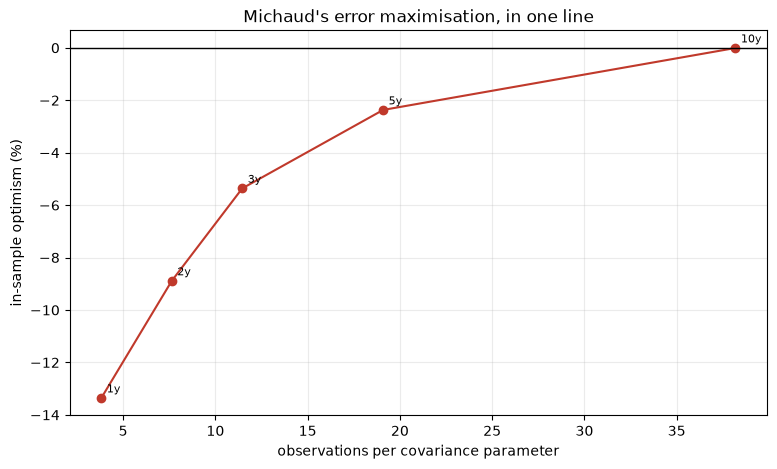

In [6]:
cexp = st.covariance_experiment(rets, sectors)
csc = cexp.groupby("window").agg(realised=("realised_vol", "mean"),
                                 predicted=("predicted_vol", "mean"),
                                 shorts=("short_weight", "mean"),
                                 turnover=("turnover", "mean"),
                                 n_assets=("n_assets", "mean"))
order = [w for w in list(st.WINDOWS_YEARS) + [st.EXPANDING] if w in csc.index]
csc = csc.loc[order]
csc["optimism"] = csc["predicted"] / csc["realised"] - 1
n = len(sectors); n_params = n * (n + 1) / 2
csc["rows_per_param"] = [(w * 252 / n_params) if w != st.EXPANDING else np.nan
                         for w in csc.index]
print(csc.round(4).to_string())
fig, ax = plt.subplots(figsize=(9, 5))
sub = csc.dropna(subset=["rows_per_param"])
ax.plot(sub["rows_per_param"], sub["optimism"] * 100, marker="o", color="#c0392b")
for w, r in sub.iterrows():
    ax.annotate(f"{w}y", (r["rows_per_param"], r["optimism"] * 100),
                xytext=(4, 4), textcoords="offset points", fontsize=8)
ax.axhline(0, color="k", lw=1)
ax.set_xlabel("observations per covariance parameter")
ax.set_ylabel("in-sample optimism (%)")
ax.set_title("Michaud's error maximisation, in one line")
plt.show()

### 4.5 The synthetic control: a world with no structural change

In [7]:
rows = []
for ss, tag in ((1.0, "stationary, planted"), (0.0, "stationary, pure noise")):
    p, _, _ = data.synthetic_panel(n_assets=8, n_years=25, signal_strength=ss, seed=967)
    r = st.to_returns(p)
    sc = st.score(st.mean_experiment(r, tuple(p.columns), windows=(1, 3, 5)))
    for w in sc.index:
        rows.append({"world": tag, "window": str(w), "mse": sc.loc[w, "mse"]})
piv = pd.DataFrame(rows).pivot(index="window", columns="world", values="mse")
print(piv.round(9).to_string())
print("\nIn a world with no structural change the expanding window must win the mean,")
print("and it does. On the real tape it wins too — which tells you sector means are")
print("closer to stationary-and-unknowable than to drifting-and-trackable.")

world      stationary, planted  stationary, pure noise
window                                                
1                       0.0000                  0.0000
3                       0.0000                  0.0000
5                       0.0000                  0.0000
expanding               0.0000                  0.0000

In a world with no structural change the expanding window must win the mean,
and it does. On the real tape it wins too — which tells you sector means are
closer to stationary-and-unknowable than to drifting-and-trackable.


## 5 · The verdict

In [8]:
summary = pd.DataFrame({
    "best window": [st.best_window(st.score(bexp)),
                    st.best_window(st.score(mexp)),
                    csc["realised"].idxmin()],
    "spread (worst/best - 1)": [
        st.score(bexp)["mse"].max() / st.score(bexp)["mse"].min() - 1,
        st.score(mexp)["mse"].max() / st.score(mexp)["mse"].min() - 1,
        csc["realised"].max() / csc["realised"].min() - 1],
}, index=["beta", "mean return", "covariance (portfolio vol)"])
summary.round(3)

,best window,spread (worst/best - 1)
beta,2,0.7200
mean return,10,0.9150
covariance (portfolio vol),3,0.0330


## 6 · Is there one default?

No — and a study that produced one would be hiding the mechanism. The defensible default is a
*rule*: estimate how many observations per parameter your estimator needs, use at least that
many, and shrink whatever is left over.

## 7 · Going further

- **Endogenous windows** via Bai-Perron break tests, or the Pesaran-Timmermann optimal-window
  criterion, instead of a grid.
- **Exponential weighting** (a half-life rather than a cliff) — smoother, one parameter.
- **Ledoit-Wolf shrinkage** on the covariance matrix, which is study **975** and which mostly
  removes the window question by making short windows safe.
- **A ragged, wide cross-section** with delistings, where the observations-per-parameter
  arithmetic becomes binding rather than merely instructive.